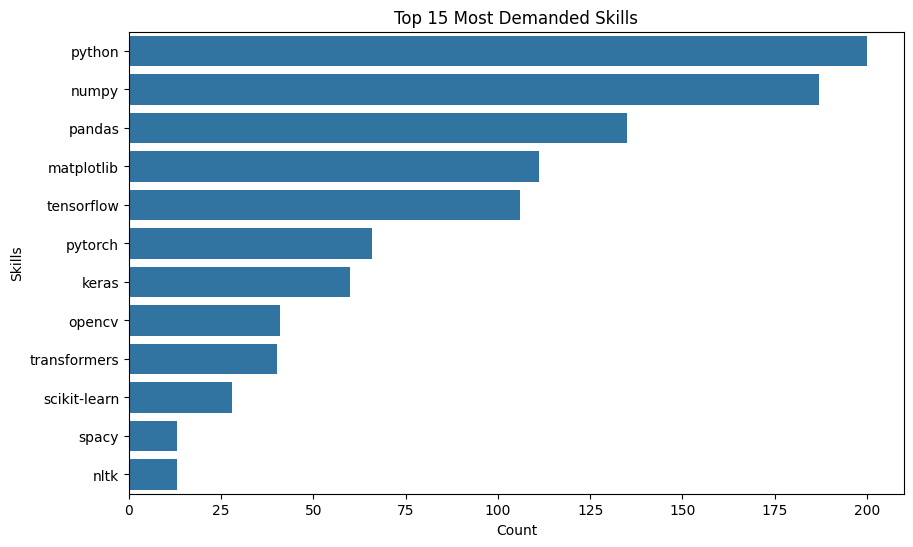


Top Job Recommendations:

Job Role: AI Engineer
Skills: Python, TensorFlow, Keras, NumPy, Pandas
Project: AI Chatbot; AI Assistant System
Industry Demand: High
Match: 55.85 %
-------------------------
Job Role: MLOps Engineer
Skills: Python, TensorFlow, Keras, Pandas, NumPy
Project: Model Deployment Pipeline; CI/CD ML System
Industry Demand: Medium
Match: 55.63 %
-------------------------


In [17]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

data = pd.read_csv("ai_job_dataset.csv")

data["combined_features"] = (
    data["skills"] + " " +
    data["education"] + " " +
    data["math_knowledge"]
)


skills_series = data["skills"].dropna().str.lower().str.split(",")

all_skills = []
for sublist in skills_series:
    for skill in sublist:
        all_skills.append(skill.strip())

skill_counts = pd.Series(all_skills).value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=skill_counts.values, y=skill_counts.index)

plt.title("Top 15 Most Demanded Skills")
plt.xlabel("Count")
plt.ylabel("Skills")
plt.savefig("Top 15 Skills ")
plt.show()

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(data["combined_features"])

user_skills = input("Enter your skills: ")

user_skills = user_skills.lower()

skills_list = [skill.strip() for skill in user_skills.split(",")]
skills_list = list(set(skills_list))
user_skills = ", ".join(skills_list)

user_vector = vectorizer.transform([user_skills])

similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()

data["score"] = similarity_scores

data_sorted = data.sort_values(by="score", ascending=False)

data_unique = data_sorted.drop_duplicates(subset="job_recommendation")

top_jobs = data_unique.head(2)

print("\nTop Job Recommendations:\n")

for _, row in top_jobs.iterrows():

    match_percentage = round(row["score"] * 100, 2)

    print("Job Role:", row["job_recommendation"])
    print("Skills:", row["skills"])
    print("Project:", row["projects"])
    print("Industry Demand:", row["industry_demand"])
    print("Match:", match_percentage, "%")
    print("-------------------------")
    pickle.dump(vectorizer, open("vectorizer_ai.pkl", "wb"))
    data.to_pickle("ai_job.pkl")
    pickle.dump(tfidf_matrix, open("tfidf_matrix_ai.pkl", "wb"))

In [18]:
import pandas as pd
data = pd.read_csv("design.csv")
data.columns

Index(['skills', 'education', 'job_recommendation', 'math_knowledge',
       'projects', 'industry_demand'],
      dtype='object')